In [27]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
# read the pickle file
with open('../tracker_stubs/ball_detections.pkl', 'rb') as f:
    ball_positions = pickle.load(f)

In [29]:
ball_positions

[{},
 {},
 {1: [863.9210815429688,
   275.71185302734375,
   874.5986328125,
   290.7032775878906]},
 {1: [851.0957641601562,
   268.7178649902344,
   860.0493774414062,
   282.6278076171875]},
 {},
 {},
 {},
 {1: [811.1348266601562,
   260.6923522949219,
   819.0593872070312,
   272.61492919921875]},
 {},
 {},
 {1: [795.4349975585938,
   275.45892333984375,
   801.6701049804688,
   285.56268310546875]},
 {1: [966.7868041992188,
   487.2015075683594,
   977.0206298828125,
   506.0876159667969]},
 {},
 {},
 {},
 {1: [775.60888671875,
   256.68927001953125,
   781.8909912109375,
   266.9129943847656]},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {1: [771.4592895507812,
   654.258056640625,
   784.5505981445312,
   681.0894775390625]},
 {1: [718.458984375, 197.1007843017578, 728.0732421875, 213.0418701171875]},
 {1: [715.9752197265625,
   212.11444091796875,
   727.97607421875,
   229.8437347412109

In [30]:
ball_positions = [x.get(1,[]) for x in ball_positions]
# convert the list into pandas dataframe
df_ball_positions = pd.DataFrame(ball_positions,columns=['x1','y1','x2','y2'])

# interpolate the missing values
df_ball_positions = df_ball_positions.interpolate()
df_ball_positions = df_ball_positions.bfill()

ball_positions = [{1:x} for x in df_ball_positions.to_numpy().tolist()]

In [31]:
df_ball_positions['mid_y'] = (df_ball_positions['y1'] + df_ball_positions['y2'])/2
df_ball_positions['mid_y_rolling_mean'] = df_ball_positions['mid_y'].rolling(window=5, min_periods=1, center=False).mean()

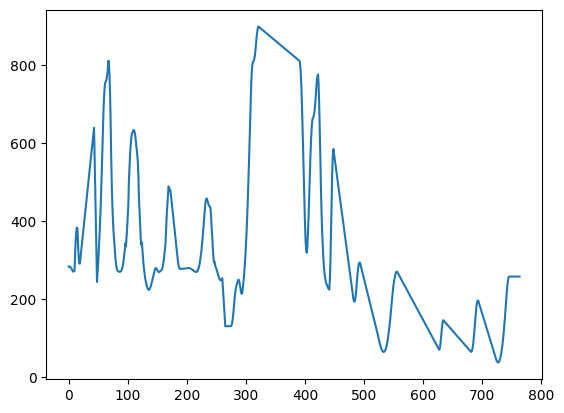

In [32]:
# plot mid_y_rolling_mean
plt.plot(df_ball_positions['mid_y_rolling_mean'])

In [33]:
df_ball_positions['delta_y'] = df_ball_positions['mid_y_rolling_mean'].diff()

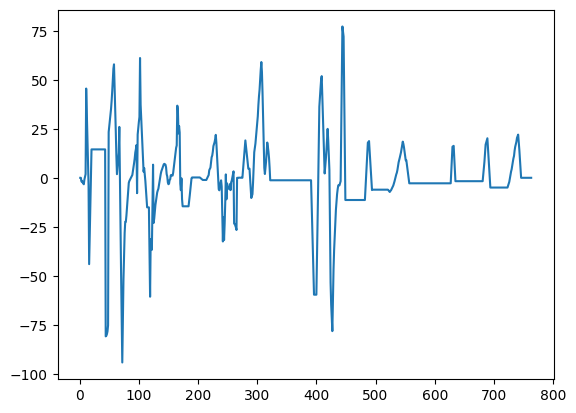

In [34]:
# plot mid_y_rolling_mean
plt.plot(df_ball_positions['delta_y'])

In [ ]:
df_ball_positions['mid_y'] = (df_ball_positions['y1'] + df_ball_positions['y2'])/2
df_ball_positions['mid_y_rolling_mean'] = df_ball_positions['mid_y'].rolling(window=5, min_periods=1, center=False).mean()
df_ball_positions['delta_y'] = df_ball_positions['mid_y_rolling_mean'].diff()

minimum_change_frames_for_hit = 15 # frames
df_ball_positions['ball_hit'] = 0

for i in range(1, len(df_ball_positions) - int(minimum_change_frames_for_hit * 1.2)):
    negative_position_change = (
        df_ball_positions['delta_y'].iloc[i] > 0 and
        df_ball_positions['delta_y'].iloc[i + 1] < 0
    )

    positive_position_change = (
        df_ball_positions['delta_y'].iloc[i] < 0 and
        df_ball_positions['delta_y'].iloc[i + 1] > 0
    )

    if negative_position_change or positive_position_change:
        change_count = 0

        for change_frame in range(i + 1, i + int(minimum_change_frames_for_hit * 1.2) + 1):
            negative_position_change_following_frame = (
                df_ball_positions['delta_y'].iloc[i] > 0 and
                df_ball_positions['delta_y'].iloc[change_frame] < 0
            )

            positive_position_change_following_frame = (
                df_ball_positions['delta_y'].iloc[i] < 0 and
                df_ball_positions['delta_y'].iloc[change_frame] > 0
            )

            if negative_position_change and negative_position_change_following_frame:
                change_count += 1
            elif positive_position_change and positive_position_change_following_frame:
                change_count += 1

        if change_count > minimum_change_frames_for_hit - 1:
            df_ball_positions.loc[i, 'ball_hit'] = 1

frame_nums_with_ball_hits = df_ball_positions[df_ball_positions['ball_hit'] == 1].index.tolist()

In [50]:
df_ball_positions[df_ball_positions['ball_hit']==1]

,x1,y1,x2,y2,mid_y,mid_y_rolling_mean,delta_y,ball_hit
19,775.016087,313.484811,782.270935,326.081063,319.782937,290.792035,-0.145810,1
48,709.026123,283.237343,719.789597,299.757713,291.497528,243.642192,-75.235248,1
67,500.272797,868.453369,520.495544,907.815369,888.134369,809.647491,25.969647,1
86,999.623206,260.160925,1015.334741,281.336096,270.748511,269.662058,-0.368979,1
110,514.328068,619.133316,532.835426,641.830238,630.481777,632.923009,1.852020,1
153,888.040754,261.933690,900.525190,281.155273,271.544482,268.862435,-0.777508,1
169,962.749817,488.426056,972.061829,505.333496,496.879776,488.248038,23.095605,1
215,795.496140,262.572067,804.921310,276.797241,269.684654,269.362580,-0.473753,1
234,1279.335083,433.754028,1289.463013,452.101929,442.927979,457.198444,0.011661,1
247,1096.595459,271.560730,1112.093750,293.114288,282.337509,295.637936,1.735370,1


In [51]:
df_ball_positions[df_ball_positions['ball_hit'] == 1].index.tolist()

[19,
 48,
 67,
 86,
 110,
 153,
 169,
 215,
 234,
 247,
 268,
 293,
 321,
 403,
 422,
 448,
 492,
 533,
 555,
 634,
 693,
 727]